# 01 — Data Preparation

## Objectif

Construire une table de modélisation pour estimer la probabilité de défaut
des prêts Lending Club, sans fuite d’information.

La cible est définie ainsi :

- `Fully Paid` : non-défaut, `default_flag = 0`
- `Charged Off` et `Default` : défaut, `default_flag = 1`

Les prêts dont l’issue est incomplète ou incertaine seront retirés.


In [11]:
# ============================================================
# 0. IMPORTS, CONFIGURATION ET CHEMINS DU PROJET
# ============================================================

# Standard library
from pathlib import Path
import gc
import warnings

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration globale
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep"
)

# ------------------------------------------------------------
# Chemins du projet
# ------------------------------------------------------------

def find_project_root(start_path: Path) -> Path:
    """
    Remonte les dossiers jusqu'à trouver la racine du projet,
    identifiée par le fichier pyproject.toml.
    """
    current_path = start_path.resolve()

    for candidate_path in [current_path, *current_path.parents]:
        if (candidate_path / "pyproject.toml").exists():
            return candidate_path

    raise FileNotFoundError(
        "Racine du projet introuvable : pyproject.toml absent."
    )


PROJECT_DIR = find_project_root(Path.cwd())

DATA_RAW_DIR = PROJECT_DIR / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_FIGURES_DIR = OUTPUT_DIR / "figures"
OUTPUT_TABLES_DIR = OUTPUT_DIR / "tables"
OUTPUT_MODELS_DIR = OUTPUT_DIR / "models"

RAW_FILE = DATA_RAW_DIR / "lending_club_accepted_raw.csv"

# Création défensive des dossiers de sortie
for directory in [
    DATA_PROCESSED_DIR,
    OUTPUT_FIGURES_DIR,
    OUTPUT_TABLES_DIR,
    OUTPUT_MODELS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

assert RAW_FILE.exists(), (
    f"Fichier source introuvable : {RAW_FILE}"
)

print(f"Racine projet : {PROJECT_DIR}")
print(f"Fichier source : {RAW_FILE.name}")
print(f"Taille source : {RAW_FILE.stat().st_size / 1024**3:.2f} Go")


Racine projet : /Users/kwamekristianlaban/Documents/Projet_perso/P2
Fichier source : lending_club_accepted_raw.csv
Taille source : 1.56 Go


In [2]:
available_columns = pd.read_csv(
    RAW_FILE,
    nrows=0,
    low_memory=False
).columns.tolist()

print(f"Nombre total de colonnes : {len(available_columns)}")
print(available_columns)


Nombre total de colonnes : 151
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_s

## Construction de la cible de défaut

La cible correspond au défaut final observé après l'octroi du prêt.

Nous conservons uniquement les prêts arrivés à maturité :

- `Fully Paid` : non-défaut (`default_flag = 0`) ;
- `Charged Off` et `Default` : défaut (`default_flag = 1`).

Les prêts actifs, en retard ou en période de grâce sont exclus car leur issue
finale n'est pas encore connue. Cette règle évite le biais de maturité.



In [13]:
# ============================================================
# 1. DÉFINITION DE LA CIBLE ET DE LA POPULATION ANALYTIQUE
# ============================================================

TARGET_COLUMN = "loan_status"
DATE_COLUMN = "issue_d"

GOOD_STATUSES = ["Fully Paid"]
BAD_STATUSES = ["Charged Off", "Default"]
MATURE_STATUSES = GOOD_STATUSES + BAD_STATUSES

CHUNK_SIZE = 200_000

print("Statuts non-défaut :", GOOD_STATUSES)
print("Statuts défaut     :", BAD_STATUSES)
print("Statuts retenus    :", MATURE_STATUSES)


Statuts non-défaut : ['Fully Paid']
Statuts défaut     : ['Charged Off', 'Default']
Statuts retenus    : ['Fully Paid', 'Charged Off', 'Default']


In [14]:
#Chargement controlé

mature_chunks = []

rows_read = 0
rows_kept = 0

for chunk_number, chunk in enumerate(
    pd.read_csv(
        RAW_FILE,
        usecols=selected_columns,
        chunksize=CHUNK_SIZE,
        low_memory=False
    ),
    start=1
):
    rows_read += len(chunk)

    # Conserver uniquement les prêts avec une issue finale connue
    mature_chunk = chunk.loc[
        chunk[TARGET_COLUMN].isin(MATURE_STATUSES)
    ].copy()

    # Créer la cible binaire
    mature_chunk["default_flag"] = (
        mature_chunk[TARGET_COLUMN]
        .isin(BAD_STATUSES)
        .astype("int8")
    )

    rows_kept += len(mature_chunk)
    mature_chunks.append(mature_chunk)

    print(
        f"Chunk {chunk_number:02d} | "
        f"lignes lues : {rows_read:>10,} | "
        f"prêts matures retenus : {rows_kept:>10,}"
    )

    del chunk, mature_chunk
    gc.collect()

modeling_df = pd.concat(mature_chunks, ignore_index=True)

del mature_chunks
gc.collect()

print("\n" + "=" * 60)
print("CHARGEMENT TERMINÉ")
print("=" * 60)
print(f"Lignes du fichier brut          : {rows_read:,}")
print(f"Prêts matures conservés         : {len(modeling_df):,}")
print(f"Part du portefeuille conservée  : {len(modeling_df) / rows_read:.2%}")
print(f"Dimensions de modeling_df       : {modeling_df.shape}")


Chunk 01 | lignes lues :    200,000 | prêts matures retenus :    176,083
Chunk 02 | lignes lues :    400,000 | prêts matures retenus :    356,181
Chunk 03 | lignes lues :    600,000 | prêts matures retenus :    422,382
Chunk 04 | lignes lues :    800,000 | prêts matures retenus :    508,120
Chunk 05 | lignes lues :  1,000,000 | prêts matures retenus :    571,494
Chunk 06 | lignes lues :  1,200,000 | prêts matures retenus :    748,291
Chunk 07 | lignes lues :  1,400,000 | prêts matures retenus :    896,197
Chunk 08 | lignes lues :  1,600,000 | prêts matures retenus :    916,209
Chunk 09 | lignes lues :  1,800,000 | prêts matures retenus :  1,053,648
Chunk 10 | lignes lues :  2,000,000 | prêts matures retenus :  1,229,863
Chunk 11 | lignes lues :  2,200,000 | prêts matures retenus :  1,310,943
Chunk 12 | lignes lues :  2,260,701 | prêts matures retenus :  1,345,350

CHARGEMENT TERMINÉ
Lignes du fichier brut          : 2,260,701
Prêts matures conservés         : 1,345,350
Part du portefeu

In [15]:
#Controle de qualité
# Contrôles de cohérence de la cible

assert modeling_df["default_flag"].isin([0, 1]).all(), (
    "Erreur : default_flag doit contenir uniquement 0 et 1."
)

assert modeling_df[TARGET_COLUMN].isin(MATURE_STATUSES).all(), (
    "Erreur : des statuts non matures sont présents."
)

assert modeling_df["id"].notna().all(), (
    "Erreur : certains prêts n'ont pas d'identifiant."
)

assert modeling_df["id"].is_unique, (
    "Erreur : des identifiants de prêts sont dupliqués."
)

target_summary = (
    modeling_df
    .groupby([TARGET_COLUMN, "default_flag"])
    .size()
    .reset_index(name="n_loans")
)

target_summary["share"] = (
    target_summary["n_loans"] / target_summary["n_loans"].sum()
)

display(target_summary)

print(f"Taux de défaut global : {modeling_df['default_flag'].mean():.2%}")
print(f"Nombre de défauts     : {modeling_df['default_flag'].sum():,}")
print(f"Nombre de non-défauts : {(modeling_df['default_flag'] == 0).sum():,}")


,loan_status,default_flag,n_loans,share
0,Charged Off,1,268559,0.1996
1,Default,1,40,0.0000
2,Fully Paid,0,1076751,0.8004


Taux de défaut global : 19.96%
Nombre de défauts     : 268,599
Nombre de non-défauts : 1,076,751


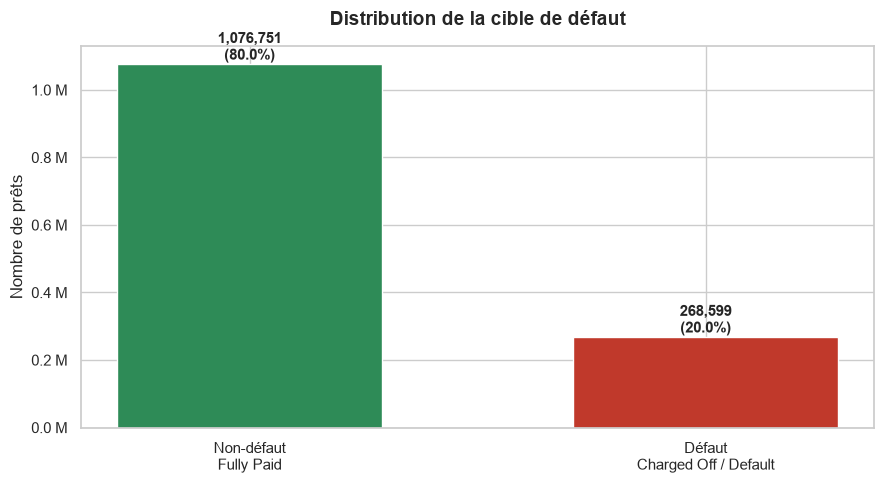

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/target_distribution.png


In [16]:
target_plot_df = (
    modeling_df["default_flag"]
    .value_counts()
    .rename_axis("default_flag")
    .reset_index(name="n_loans")
    .sort_values("default_flag")
)

target_plot_df["loan_outcome"] = target_plot_df["default_flag"].map({
    0: "Non-défaut\nFully Paid",
    1: "Défaut\nCharged Off / Default",
})

target_plot_df["share"] = (
    target_plot_df["n_loans"] / target_plot_df["n_loans"].sum()
)

fig, ax = plt.subplots(figsize=(9, 5))

bar_colors = ["#2E8B57", "#C0392B"]

bars = ax.bar(
    target_plot_df["loan_outcome"],
    target_plot_df["n_loans"],
    color=bar_colors,
    width=0.58
)

for bar, (_, row) in zip(bars, target_plot_df.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{row['n_loans']:,}\n({row['share']:.1%})",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "Distribution de la cible de défaut",
    fontsize=14,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("")
ax.set_ylabel("Nombre de prêts")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value / 1_000_000:.1f} M")
)

plt.tight_layout()

figure_path = OUTPUT_FIGURES_DIR / "target_distribution.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Figure exportée : {figure_path}")


### Interprétation

La population de prêts arrivés à maturité est déséquilibrée : les non-défauts
sont majoritaires, mais le nombre de défauts reste matériel.

L'accuracy ne sera donc pas utilisée comme métrique principale, car un modèle
qui prédit systématiquement « non-défaut » pourrait obtenir un résultat
trompeusement élevé.

Les futurs modèles seront principalement évalués selon leur capacité à
discriminer les défauts (ROC-AUC, Gini, KS, AUC-PR) et à prédire des
probabilités réalistes (calibration et Brier score).


Graphique — Déséquilibre de cible
Pourquoi ce graphique ?
Il permet de vérifier le niveau du déséquilibre entre défauts et non-défauts. Cela justifiera, dans les notebooks de modélisation, l’évaluation par AUC-PR, Gini, KS et calibration plutôt qu’une simple accuracy.

## Préparation temporelle et validation hors échantillon

La date d'octroi `issue_d` est convertie au format date, puis utilisée pour
séparer le portefeuille chronologiquement.

Le modèle n'a accès qu'aux prêts anciens durant l'entraînement. Les années
2016 et 2017–2018 sont réservées respectivement à la validation et au test
final. Cette approche reproduit une mise en production réelle et évite toute
fuite temporelle entre les jeux de données.


In [17]:
#Conversion de date
# ============================================================
# 2. PRÉPARATION DE LA DIMENSION TEMPORELLE
# ============================================================

modeling_df[DATE_COLUMN] = pd.to_datetime(
    modeling_df[DATE_COLUMN],
    format="%b-%Y",
    errors="coerce"
)

date_quality = pd.DataFrame({
    "metric": [
        "Nombre total de prêts",
        "Dates manquantes ou invalides",
        "Date minimale",
        "Date maximale",
    ],
    "value": [
        f"{len(modeling_df):,}",
        f"{modeling_df[DATE_COLUMN].isna().sum():,}",
        modeling_df[DATE_COLUMN].min().strftime("%Y-%m-%d"),
        modeling_df[DATE_COLUMN].max().strftime("%Y-%m-%d"),
    ]
})

display(date_quality)

# Une date d'octroi inconnue empêche tout split temporel fiable
rows_before_date_filter = len(modeling_df)

modeling_df = modeling_df.dropna(subset=[DATE_COLUMN]).copy()

print(
    "Prêts retirés pour date d'octroi absente ou invalide : "
    f"{rows_before_date_filter - len(modeling_df):,}"
)
print(f"Prêts restants : {len(modeling_df):,}")


,metric,value
0,Nombre total de prêts,"1,345,350"
1,Dates manquantes ou invalides,0
2,Date minimale,2007-06-01
3,Date maximale,2018-12-01


Prêts retirés pour date d'octroi absente ou invalide : 0
Prêts restants : 1,345,350


In [18]:
#Attribution des jeux
# Dates de coupure du split temporel
TRAIN_END_DATE = pd.Timestamp("2015-12-31")
VALIDATION_END_DATE = pd.Timestamp("2016-12-31")

modeling_df["dataset_split"] = np.select(
    [
        modeling_df[DATE_COLUMN] <= TRAIN_END_DATE,
        modeling_df[DATE_COLUMN] <= VALIDATION_END_DATE,
    ],
    [
        "train",
        "validation",
    ],
    default="test"
)

split_order = ["train", "validation", "test"]

split_summary = (
    modeling_df
    .groupby("dataset_split", observed=True)
    .agg(
        start_date=(DATE_COLUMN, "min"),
        end_date=(DATE_COLUMN, "max"),
        n_loans=("id", "size"),
        n_defaults=("default_flag", "sum"),
        default_rate=("default_flag", "mean"),
    )
    .reindex(split_order)
    .reset_index()
)

split_summary["share_loans"] = (
    split_summary["n_loans"] / split_summary["n_loans"].sum()
)

split_summary["start_date"] = split_summary["start_date"].dt.strftime("%Y-%m")
split_summary["end_date"] = split_summary["end_date"].dt.strftime("%Y-%m")

display(split_summary)

assert set(modeling_df["dataset_split"].unique()) == set(split_order), (
    "Erreur : au moins un des jeux train, validation ou test est vide."
)

assert (
    modeling_df.loc[modeling_df["dataset_split"] == "train", DATE_COLUMN].max()
    <= TRAIN_END_DATE
), "Erreur : le train contient des prêts postérieurs à décembre 2015."

assert (
    modeling_df.loc[
        modeling_df["dataset_split"] == "validation", DATE_COLUMN
    ].min()
    > TRAIN_END_DATE
), "Erreur : la validation chevauche la période train."

assert (
    modeling_df.loc[modeling_df["dataset_split"] == "test", DATE_COLUMN].min()
    > VALIDATION_END_DATE
), "Erreur : le test chevauche la période validation."

split_summary.to_csv(
    OUTPUT_TABLES_DIR / "temporal_split_summary.csv",
    index=False
)


,dataset_split,start_date,end_date,n_loans,n_defaults,default_rate,share_loans
0,train,2007-06,2015-12,826606,152304,0.1843,0.6144
1,validation,2016-01,2016-12,293105,68252,0.2329,0.2179
2,test,2017-01,2018-12,225639,48043,0.2129,0.1677


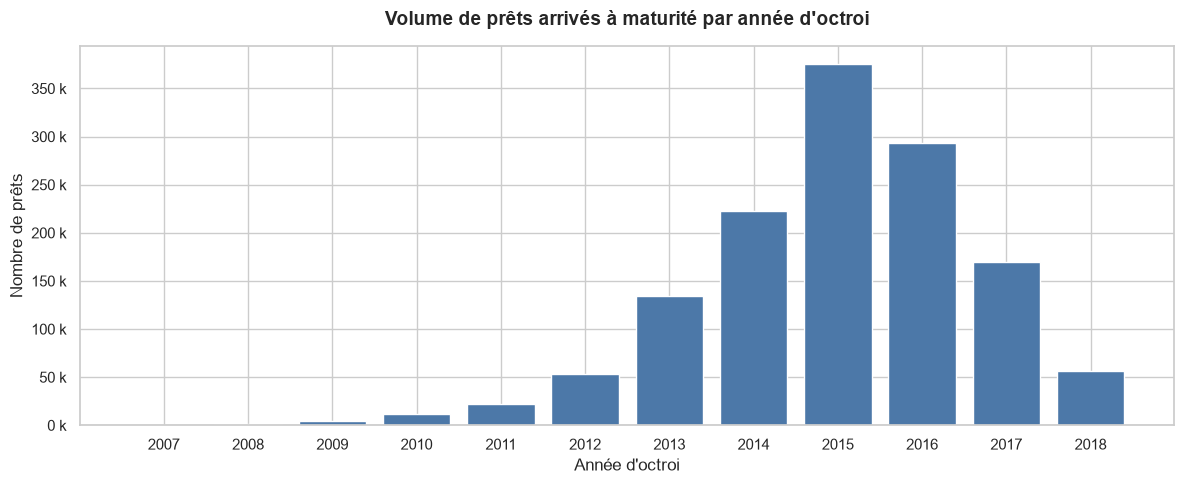

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/loan_volume_by_vintage.png


In [19]:
vintage_volume = (
    modeling_df
    .assign(issue_year=modeling_df[DATE_COLUMN].dt.year)
    .groupby("issue_year", observed=True)
    .size()
    .reset_index(name="n_loans")
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    vintage_volume["issue_year"].astype(str),
    vintage_volume["n_loans"],
    color="#4C78A8"
)

ax.set_title(
    "Volume de prêts arrivés à maturité par année d'octroi",
    fontsize=14,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Année d'octroi")
ax.set_ylabel("Nombre de prêts")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value / 1_000:.0f} k")
)

plt.tight_layout()

figure_path = OUTPUT_FIGURES_DIR / "loan_volume_by_vintage.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Figure exportée : {figure_path}")


Graphique 1 — Volumes par millésime
Pourquoi ce graphique ?
Il montre combien de prêts composent chaque période et vérifie que le test contient un volume suffisant. Il signale aussi les changements éventuels de portefeuille au fil du temps.

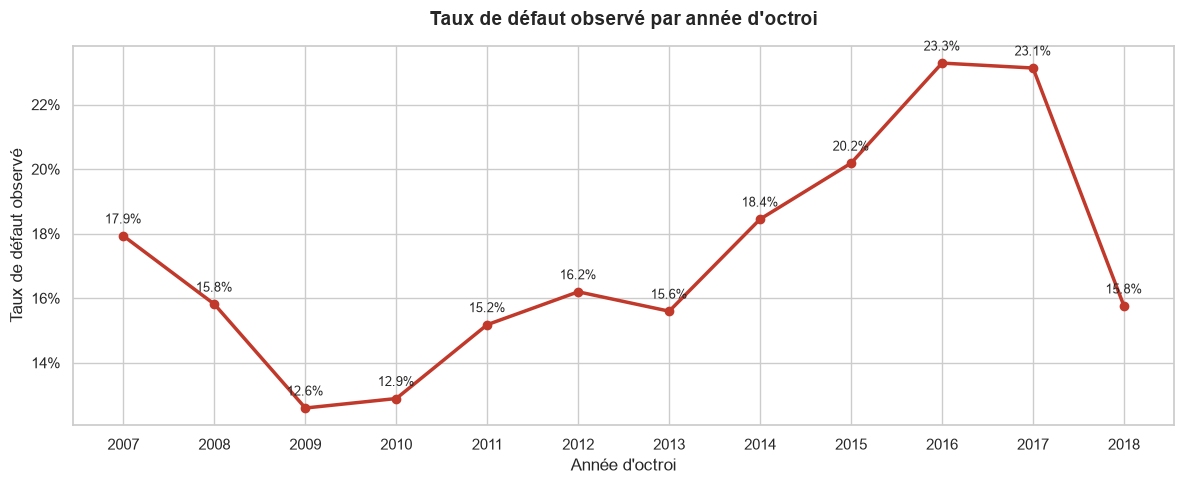

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/default_rate_by_vintage.png


In [20]:
vintage_default_rate = (
    modeling_df
    .assign(issue_year=modeling_df[DATE_COLUMN].dt.year)
    .groupby("issue_year", observed=True)
    .agg(
        n_loans=("id", "size"),
        default_rate=("default_flag", "mean")
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    vintage_default_rate["issue_year"],
    vintage_default_rate["default_rate"],
    marker="o",
    linewidth=2.5,
    color="#C0392B"
)

for _, row in vintage_default_rate.iterrows():
    ax.annotate(
        f"{row['default_rate']:.1%}",
        (row["issue_year"], row["default_rate"]),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

ax.set_title(
    "Taux de défaut observé par année d'octroi",
    fontsize=14,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Année d'octroi")
ax.set_ylabel("Taux de défaut observé")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)
ax.set_xticks(vintage_default_rate["issue_year"])

plt.tight_layout()

figure_path = OUTPUT_FIGURES_DIR / "default_rate_by_vintage.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Figure exportée : {figure_path}")


Graphique 2 — Taux de défaut par millésime
Pourquoi ce graphique ?
Le taux de défaut par année d’octroi est un premier test de stabilité. Des différences fortes entre années justifient le split chronologique et annoncent le besoin de monitoring dans un contexte de production.

### Interprétation

Le split est strictement chronologique : les prêts du jeu de test sont
postérieurs à ceux utilisés pendant l'entraînement et la validation.

Les variations de volume et de taux de défaut selon le millésime confirment
que les données ne sont pas parfaitement stationnaires dans le temps. Un
split aléatoire aurait masqué une partie de ce risque de dérive et conduit à
une estimation trop optimiste de la performance future.

Les métriques finales seront donc toujours reportées séparément sur la
validation et sur le test hors échantillon.


### Interprétation

Le taux de défaut varie sensiblement selon le millésime d'octroi : il passe de
18,4 % sur le jeu d'entraînement à 23,3 % sur la validation 2016, puis à
21,3 % sur le test 2017–2018.

Cette évolution confirme l'existence d'une dérive temporelle du portefeuille.
Un split aléatoire aurait mélangé les environnements de risque et produit une
évaluation artificiellement optimiste de la performance future.

La baisse observée en 2018 doit toutefois être interprétée avec prudence.
Les prêts récents disposent d'une durée d'observation plus courte ; en
excluant les prêts encore actifs, on conserve une population non représentative
de l'ensemble des octrois 2018. Cette limite sera documentée dans le README
et complétée par une analyse de maturité par durée de prêt.


## Diagnostic de maturité des cohortes

La définition de la cible conserve uniquement les prêts avec une issue finale
connue. Toutefois, les cohortes récentes peuvent ne pas avoir eu le temps
d'atteindre leur échéance contractuelle.

Nous estimons donc, pour chaque prêt, si sa durée contractuelle était
théoriquement terminée à la date de référence de l'extraction.

Ce contrôle est réalisé par millésime et par durée (`36 months` ou
`60 months`) afin d'identifier les cohortes exposées à une censure temporelle.


In [21]:
#Paramètres et lecture minimale
# ============================================================
# 3. DIAGNOSTIC DE MATURITÉ DES COHORTES
# ============================================================

OBSERVATION_CUTOFF_DATE = pd.Timestamp("2019-03-31")

MATURITY_COLUMNS = [
    "id",
    "issue_d",
    "term",
    "loan_status",
]

maturity_chunks = []

for chunk in pd.read_csv(
    RAW_FILE,
    usecols=MATURITY_COLUMNS,
    chunksize=CHUNK_SIZE,
    low_memory=False
):
    chunk["issue_d"] = pd.to_datetime(
        chunk["issue_d"],
        format="%b-%Y",
        errors="coerce"
    )

    # " 36 months" -> 36 ; " 60 months" -> 60
    chunk["term_months"] = (
        chunk["term"]
        .str.extract(r"(\d+)", expand=False)
        .astype("float")
    )

    # Date d'échéance théorique du prêt
    chunk["contractual_end_date"] = (
        chunk["issue_d"]
        + pd.to_timedelta(chunk["term_months"] * 30.4375, unit="D")
    )

    # Indicateur : durée contractuelle entièrement écoulée à la date d'observation
    chunk["contractually_mature"] = (
        chunk["contractual_end_date"] <= OBSERVATION_CUTOFF_DATE
    )

    maturity_chunks.append(
        chunk[
            [
                "id",
                "issue_d",
                "term",
                "term_months",
                "loan_status",
                "contractual_end_date",
                "contractually_mature",
            ]
        ]
    )

maturity_df = pd.concat(maturity_chunks, ignore_index=True)

del maturity_chunks
gc.collect()

print(f"Date de référence : {OBSERVATION_CUTOFF_DATE:%Y-%m-%d}")
print(f"Prêts analysés    : {len(maturity_df):,}")
print(
    "Prêts contractuellement matures : "
    f"{maturity_df['contractually_mature'].mean():.1%}"
)


Date de référence : 2019-03-31
Prêts analysés    : 2,260,701
Prêts contractuellement matures : 34.8%


In [22]:
#Tableau de maturité par millésime
maturity_df["issue_year"] = maturity_df["issue_d"].dt.year

maturity_summary = (
    maturity_df
    .groupby(["issue_year", "term_months"], observed=True)
    .agg(
        n_loans=("id", "size"),
        n_contractually_mature=("contractually_mature", "sum"),
        maturity_rate=("contractually_mature", "mean"),
    )
    .reset_index()
    .sort_values(["issue_year", "term_months"])
)

maturity_summary["n_not_mature"] = (
    maturity_summary["n_loans"]
    - maturity_summary["n_contractually_mature"]
)

maturity_summary["term_label"] = (
    maturity_summary["term_months"]
    .astype("Int64")
    .astype(str)
    + " months"
)

display(maturity_summary)

maturity_summary.to_csv(
    OUTPUT_TABLES_DIR / "maturity_by_vintage_and_term.csv",
    index=False
)


,issue_year,term_months,n_loans,n_contractually_mature,maturity_rate,n_not_mature,term_label
0,"2,007.0000",36.0000,603,603,1.0000,0,36 months
1,"2,008.0000",36.0000,2393,2393,1.0000,0,36 months
2,"2,009.0000",36.0000,5281,5281,1.0000,0,36 months
3,"2,010.0000",36.0000,9156,9156,1.0000,0,36 months
4,"2,010.0000",60.0000,3381,3381,1.0000,0,60 months
5,"2,011.0000",36.0000,14101,14101,1.0000,0,36 months
6,"2,011.0000",60.0000,7620,7620,1.0000,0,60 months
7,"2,012.0000",36.0000,43470,43470,1.0000,0,36 months
8,"2,012.0000",60.0000,9897,9897,1.0000,0,60 months
9,"2,013.0000",36.0000,100422,100422,1.0000,0,36 months


Graphique — Maturité par année et durée
Pourquoi ce graphique ?
Ce graphique indique quelles cohortes sont réellement exploitables pour construire une cible PD sans forte censure temporelle.
•	Une proportion proche de 100% signifie que les prêts de la cohorte ont, en théorie, dépassé leur échéance contractuelle.
•	Une proportion faible signifie que les prêts sont récents ; leurs statuts finaux sont incomplets.
•	Les prêts à 60 mois seront naturellement matures beaucoup plus tard que ceux à 36 mois.

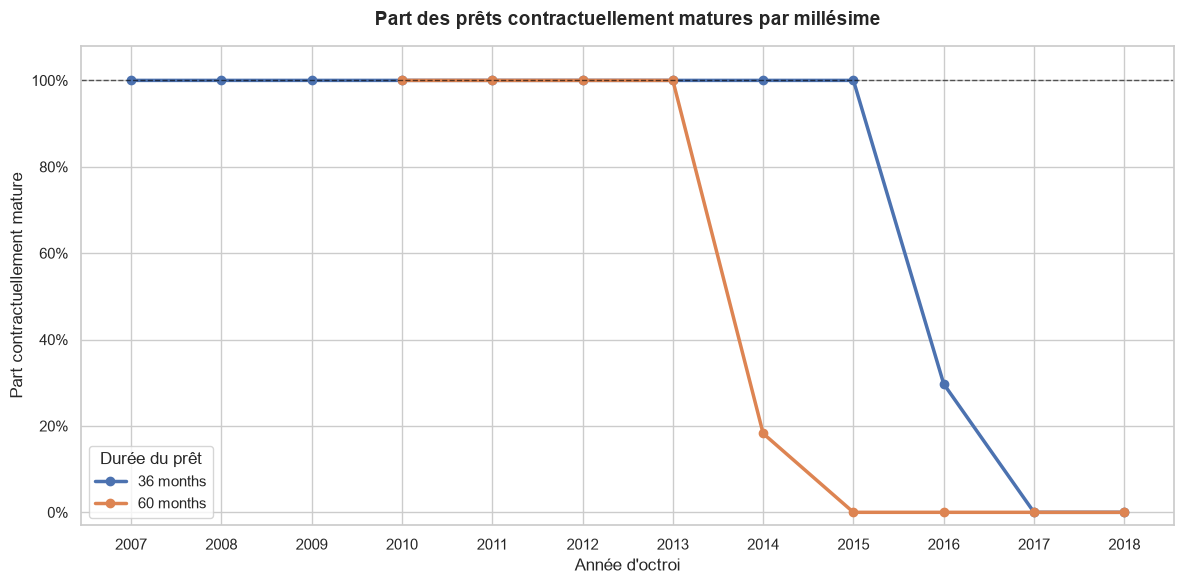

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/maturity_rate_by_vintage_and_term.png


In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

for term_months, term_data in maturity_summary.groupby("term_months"):
    ax.plot(
        term_data["issue_year"],
        term_data["maturity_rate"],
        marker="o",
        linewidth=2.5,
        label=f"{int(term_months)} months"
    )

ax.axhline(
    y=1.0,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

ax.set_title(
    "Part des prêts contractuellement matures par millésime",
    fontsize=14,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Année d'octroi")
ax.set_ylabel("Part contractuellement mature")
ax.set_xticks(sorted(maturity_summary["issue_year"].dropna().unique()))
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)
ax.set_ylim(-0.03, 1.08)

ax.legend(
    title="Durée du prêt",
    frameon=True
)

plt.tight_layout()

figure_path = OUTPUT_FIGURES_DIR / "maturity_rate_by_vintage_and_term.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Figure exportée : {figure_path}")
